In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sphere(x):
    return np.sum(x**2)

def init_pop(pop_size, dim, bounds):
    return np.random.uniform(bounds[0], bounds[1], (pop_size, dim))

In [ ]:
def BCGA(dim, bounds, pop_size, max_iterations):
    # 16 bits for better precision
    bits = 16 
    total_bits = dim * bits
    max_val = (2**bits) - 1
    
    # Standard heuristic: Mutation should hover around 1 / total_bits
    MUT_MAX = 0.05               # 5% for early exploration
    MUT_MIN = 1.0 / total_bits   # ~0.6% for final fine-grained exploitation

    pop = np.random.randint(2, size=(pop_size, total_bits))
    history = []
    
    # Pre-calculate powers of 2 for rapid vectorized decoding
    powers_of_two = 2 ** np.arange(bits)[::-1]

    def decode_population(pop_matrix):
        """Vectorized decoding of the entire population at once."""
        # Reshape to isolate each dimension's bits: (pop_size, dim, bits)
        reshaped = pop_matrix.reshape(pop_size, dim, bits)
        
        # Dot product with powers of 2 converts binary arrays straight to integers
        decimals = reshaped.dot(powers_of_two)
        
        # Map to continuous bounded space
        return bounds[0] + (decimals / max_val) * (bounds[1] - bounds[0])

    def tournament(fitness, k=3):
        # Returns the index of the winner to avoid copying arrays unnecessarily
        idx = np.random.choice(pop_size, k, replace=False)
        return idx[np.argmin(fitness[idx])]

    global_best = float('inf')
    best_individual = None

    for gen in range(max_iterations):
        # 1. Fast Vectorized Fitness Evaluation
        real_vectors = decode_population(pop)
        fitness = np.apply_along_axis(sphere, 1, real_vectors)

        # 2. Track Best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < global_best:
            global_best = fitness[best_idx]
            best_individual = pop[best_idx].copy()

        history.append(global_best)

        new_pop = np.zeros_like(pop)

        # Elitism (Preserve the absolute best)
        new_pop[0] = best_individual.copy()

        # 3. Reproduction
        for i in range(1, pop_size, 2):
            # Selection
            p1_idx = tournament(fitness)
            p2_idx = tournament(fitness)
            
            p1 = pop[p1_idx]
            p2 = pop[p2_idx]

            # Crossover (Gene-aligned multipoint or single point)
            if np.random.rand() < 0.8:
                pt = np.random.randint(1, total_bits - 1)
                c1 = np.concatenate([p1[:pt], p2[pt:]])
                c2 = np.concatenate([p2[:pt], p1[pt:]])
            else:
                c1, c2 = p1.copy(), p2.copy()
                
            new_pop[i] = c1
            if i + 1 < pop_size:
                new_pop[i + 1] = c2

        # 4. Fast Vectorized Mutation (Applied to new generation, excluding the elite)
        current_mut_rate = MUT_MAX - ((MUT_MAX - MUT_MIN) * (gen / max_iterations))
        
        # Generate a random mask for the entire population simultaneously
        mutation_mask = np.random.rand(pop_size - 1, total_bits) < current_mut_rate
        
        # Apply bit flip (XOR) only where the mask is True
        new_pop[1:] ^= mutation_mask

        pop = new_pop

    return history, global_best

In [ ]:
def RCGA(dim, bounds, pop_size, max_iterations):
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))
    history = []

    def tournament(pop, fitness, k=3):
        idx = np.random.choice(len(pop), k, replace=False)
        return pop[idx[np.argmin(fitness[idx])]]

    global_best = float('inf')
    best_individual = None

    for gen in range(max_iterations):
        fitness = np.apply_along_axis(sphere, 1, pop)

        # Track best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < global_best:
            global_best = fitness[best_idx]
            best_individual = pop[best_idx].copy()

        history.append(global_best)

        new_pop = []

        # Elitism
        new_pop.append(best_individual.copy())

        # Adaptive mutation strength (better schedule)
        sigma = 0.3 * (1 - gen/max_iterations) + 0.05

        while len(new_pop) < pop_size:
            # Selection
            p1 = tournament(pop, fitness)
            p2 = tournament(pop, fitness)

            # BLX-alpha crossover (better than simple arithmetic)
            if np.random.rand() < 0.8:
                alpha = 0.5
                cmin = np.minimum(p1, p2)
                cmax = np.maximum(p1, p2)
                diff = cmax - cmin

                o1 = np.random.uniform(cmin - alpha * diff, cmax + alpha * diff)
                o2 = np.random.uniform(cmin - alpha * diff, cmax + alpha * diff)
            else:
                o1, o2 = p1.copy(), p2.copy()
                
            # Mutation (Gaussian — always applied probabilistically)
            mutation_rate = 0.2
            for o in [o1, o2]:
                mask = np.random.rand(dim) < mutation_rate
                o[mask] += np.random.normal(0, sigma, np.sum(mask))

                # REFLECTIVE BOUNDARIES (The Fix)
                lower_violations = o < bounds[0]
                o[lower_violations] = bounds[0] + (bounds[0] - o[lower_violations])
                
                upper_violations = o > bounds[1]
                o[upper_violations] = bounds[1] - (o[upper_violations] - bounds[1])

            new_pop.extend([o1, o2])

        pop = np.array(new_pop[:pop_size])

    return history, global_best

In [ ]:
def PSO(dim, bounds, pop_size, max_iterations):
    pos = init_pop(pop_size, dim, bounds)
    v_max = 0.15 * (bounds[1] - bounds[0])
    vel = np.random.uniform(-v_max, v_max, (pop_size, dim))
    
    pbest, pbest_fit = pos.copy(), np.full(pop_size, float('inf'))
    gbest, gbest_fit = None, float('inf')
    history = []
    
    for it in range(max_iterations):
        w = 0.9 - 0.5 * (it / max_iterations)
        
        fit = np.apply_along_axis(sphere, 1, pos)
        
        imp = fit < pbest_fit
        pbest[imp], pbest_fit[imp] = pos[imp], fit[imp]
        if np.min(pbest_fit) < gbest_fit:
            gbest_fit = np.min(pbest_fit)
            gbest = pbest[np.argmin(pbest_fit)].copy()
            
        history.append(gbest_fit)
        
        r1, r2 = np.random.rand(pop_size, dim), np.random.rand(pop_size, dim)
        vel = w*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
        vel = np.clip(vel, -v_max, v_max)
        
        # Calculate new positions temporarily
        new_pos = pos + vel
        
        # REFLECTIVE BOUNDARY HANDLING (The Fix)
        # Lower bound violation (bounces back into positive space)
        lower_violations = new_pos < bounds[0]
        new_pos[lower_violations] = bounds[0] + (bounds[0] - new_pos[lower_violations])
        vel[lower_violations] *= -0.5 # Reverse and dampen velocity
        
        # Upper bound violation (bounces back into valid space)
        upper_violations = new_pos > bounds[1]
        new_pos[upper_violations] = bounds[1] - (new_pos[upper_violations] - bounds[1])
        vel[upper_violations] *= -0.5 # Reverse and dampen velocity
        
        # Update positions safely
        pos = new_pos
        
    return history, gbest_fit

In [ ]:
def TLBO(dim, bounds, pop_size, max_iterations = 100):
    pop = init_pop(pop_size, dim, bounds)
    fit = np.apply_along_axis(sphere, 1, pop)
    history = []
    global_best = np.min(fit)
    
    # TLBO uses 2 evals per individual per iteration
    for _ in range(max_iterations): 
        # 1. Teacher Phase
        teacher = pop[np.argmin(fit)]
        x_mean = np.mean(pop, axis=0)
        
        for i in range(pop_size):
            tf = np.random.randint(1, 3)
            r1 = np.random.rand(dim)

            x_new = pop[i] + r1 * (teacher - tf * x_mean)
            
            # -- Reflective Boundaries --
            lower_violations = x_new < bounds[0]
            x_new[lower_violations] = bounds[0] + (bounds[0] - x_new[lower_violations])
            upper_violations = x_new > bounds[1]
            x_new[upper_violations] = bounds[1] - (x_new[upper_violations] - bounds[1])
            
            new_fit = sphere(x_new)
            if new_fit < fit[i]: 
                pop[i], fit[i] = x_new, new_fit
            

        # 2. Learner Phase
        for i in range(pop_size):
            j = np.random.randint(0, pop_size)
            while j == i: j = np.random.randint(0, pop_size)
            
            r2 = np.random.rand(dim)
            if fit[i] < fit[j]:
                x_new = pop[i] + r2 * (pop[i] - pop[j])  
            else:
                x_new = pop[i] + r2 * (pop[j] - pop[i])
                
            # -- Reflective Boundaries --
            lower_violations = x_new < bounds[0]
            x_new[lower_violations] = bounds[0] + (bounds[0] - x_new[lower_violations])
            upper_violations = x_new > bounds[1]
            x_new[upper_violations] = bounds[1] - (x_new[upper_violations] - bounds[1])
            
            new_fit = sphere(x_new)
            if new_fit < fit[i]: 
                pop[i], fit[i] = x_new, new_fit
            
        # Update global best
        if np.min(fit) < global_best: 
            global_best = np.min(fit)
    
        history.append(global_best) 
        
    return history, global_best

In [ ]:
def DE(dim, bounds, pop_size, max_iterations):
    pop = init_pop(pop_size, dim, bounds)
    fit = np.apply_along_axis(sphere, 1, pop)
    history = []
    global_best = np.min(fit)
    
    for _ in range(max_iterations):
        for i in range(pop_size):
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(idxs, 3, replace=False)
            mutant = np.clip(pop[r1] + 0.8 * (pop[r2] - pop[r3]), bounds[0], bounds[1])
            
            trial = np.copy(pop[i])
            j_rand = np.random.randint(0, dim)
            cross_points = np.random.rand(dim) <= 0.8
            cross_points[j_rand] = True
            trial[cross_points] = mutant[cross_points]
            
            trial_fit = sphere(trial)
            if trial_fit <= fit[i]:
                pop[i], fit[i] = trial, trial_fit
                if trial_fit < global_best: global_best = trial_fit
                
        history.append(global_best)
    return history, global_best

In [ ]:
def ABC(dim, bounds, pop_size, max_iterations):
    n_sources = pop_size // 2
    pop = init_pop(n_sources, dim, bounds)
    obj = np.apply_along_axis(sphere, 1, pop)
    fit = 1.0 / (1.0 + obj)
    trials = np.zeros(n_sources)
    limit = 15
    history = []
    global_best = np.min(obj)
    
    for _ in range(max_iterations):
        
        # 1. Employed Bee Phase
        for i in range(n_sources):
            k = np.random.randint(0, n_sources)
            while k == i: k = np.random.randint(0, n_sources)
            j = np.random.randint(0, dim)
            
            trial = pop[i].copy()
            new_val = trial[j] + np.random.uniform(-1, 1) * (trial[j] - pop[k,j])
            
            # -- Reflective Boundary Handling --
            if new_val < bounds[0]:
                trial[j] = bounds[0] + (bounds[0] - new_val)
            elif new_val > bounds[1]:
                trial[j] = bounds[1] - (new_val - bounds[1])
            else:
                trial[j] = new_val
                
            trial_obj = sphere(trial)
            trial_fit = 1.0 / (1.0 + trial_obj)
            
            if trial_fit > fit[i]:
                pop[i], obj[i], fit[i], trials[i] = trial, trial_obj, trial_fit, 0
            else: 
                trials[i] += 1
            
        
        # 2. Onlooker Bee Phase
        prob = fit / np.sum(fit)
        t, i = 0, 0
        while t < n_sources:
            if np.random.rand() < prob[i]:
                t += 1
                k = np.random.randint(0, n_sources)
                while k == i: k = np.random.randint(0, n_sources)
                j = np.random.randint(0, dim)
                
                trial = pop[i].copy()
                new_val = trial[j] + np.random.uniform(-1, 1) * (trial[j] - pop[k,j])
                
                # -- Reflective Boundary Handling --
                if new_val < bounds[0]:
                    trial[j] = bounds[0] + (bounds[0] - new_val)
                elif new_val > bounds[1]:
                    trial[j] = bounds[1] - (new_val - bounds[1])
                else:
                    trial[j] = new_val
                    
                trial_obj = sphere(trial)
                trial_fit = 1.0 / (1.0 + trial_obj)
                
                if trial_fit > fit[i]:
                    pop[i], obj[i], fit[i], trials[i] = trial, trial_obj, trial_fit, 0
                else: 
                    trials[i] += 1
            i = (i + 1) % n_sources
            
        
        # 3. Scout Bee Phase
        for i in range(n_sources):
            if trials[i] >= limit:
                pop[i] = np.random.uniform(bounds[0], bounds[1], dim)
                obj[i] = sphere(pop[i])
                fit[i] = 1.0 / (1.0 + obj[i])
                trials[i] = 0
                
        if np.min(obj) < global_best: 
            global_best = np.min(obj)
        history.append(global_best)
        
    return history, global_best

In [ ]:
def ACO(dim, bounds, pop_size, max_iterations):
    arc = init_pop(pop_size, dim, bounds)
    fit = np.apply_along_axis(sphere, 1, arc)
    sort_idx = np.argsort(fit)
    arc, fit = arc[sort_idx], fit[sort_idx]
    
    q, xi = 0.1, 0.85
    ranks = np.arange(1, pop_size + 1)
    weights = np.exp(-((ranks - 1)**2) / (2 * q**2 * pop_size**2))
    probs = weights / np.sum(weights)
    
    history = []
    for _ in range(max_iterations):
        new_ants = np.zeros_like(arc)
        for i in range(pop_size):
            guide_idx = np.random.choice(pop_size, p=probs)
            sigma = xi * np.mean(np.abs(arc - arc[guide_idx]), axis=0)
            new_ants[i] = np.clip(np.random.normal(arc[guide_idx], sigma), bounds[0], bounds[1])
            
        new_fit = np.apply_along_axis(sphere, 1, new_ants)
        arc = np.vstack((arc, new_ants))
        fit = np.concatenate((fit, new_fit))
        
        sort_idx = np.argsort(fit)[:pop_size]
        arc, fit = arc[sort_idx], fit[sort_idx]
        history.append(fit[0])
    return history, fit[0]

In [ ]:
# Main Execution
if __name__ == "__main__":
    np.random.seed(42) # Reproducibility for technical report
    
    DIMENSIONS = 10
    BOUNDS = (0, 30)
    POP_SIZE = 50
    MAX_ITERATIONS = 100
    NUM_TRIALS = 20

    algorithms = {
    'BCGA': BCGA,
    'RCGA': RCGA,
    'PSO': PSO,
    'TLBO': TLBO,
    'DE': DE,
    'ABC': ABC,
    'ACO': ACO
    }

    all_histories = {}
    mean_results = {}
    std_results = {}
    best_results = {}
    time_results = {}

    print("\n===== Statistical Results over 20 Runs =====\n")
print(f"{'Algo':<6} | {'Mean':<12} | {'Std Dev':<12} | {'Best':<12} | {'Avg Time (s)':<12}")
print("-" * 75)

for name, algo in algorithms.items():
    histories = []
    final_values = []
    times = []

    for trial in range(NUM_TRIALS):
        np.random.seed(42 + trial)

        start_time = time.time()  # start

        hist, best = algo(DIMENSIONS, BOUNDS, POP_SIZE, MAX_ITERATIONS)

        end_time = time.time()  # end

        hist = np.array(hist)
        hist = np.maximum(hist, 1e-30)

        histories.append(hist)
        final_values.append(hist[-1])
        times.append(end_time - start_time)

    histories = np.array(histories)
    all_histories[name] = histories

    # Statistics
    mean_val = np.mean(final_values)
    std_val = np.std(final_values)
    best_val = np.min(final_values)
    avg_time = np.mean(times)

    mean_results[name] = mean_val
    std_results[name] = std_val
    best_results[name] = best_val
    time_results[name] = avg_time

    print(f"{name:<6} | {mean_val:.6e} | {std_val:.6e} | {best_val:.6e} | {avg_time:.4f}")


===== Statistical Results over 20 Runs =====

Algo   | Mean         | Std Dev      | Best         | Avg Time (s)
---------------------------------------------------------------------------
BCGA   | 1.660680e-01 | 9.166762e-02 | 2.204675e-02 | 0.1825
RCGA   | 2.727109e-03 | 7.404999e-04 | 1.413759e-03 | 0.3524
PSO    | 5.939006e-13 | 1.005854e-12 | 7.316259e-15 | 0.0406
TLBO   | 2.446202e-30 | 2.688311e-30 | 1.000000e-30 | 0.2869
DE     | 2.122904e-06 | 5.537887e-06 | 1.000000e-30 | 0.3080
ABC    | 2.319481e-02 | 2.016767e-02 | 9.957353e-04 | 0.1293
ACO    | 5.006171e-24 | 1.468324e-23 | 3.673538e-30 | 0.3949


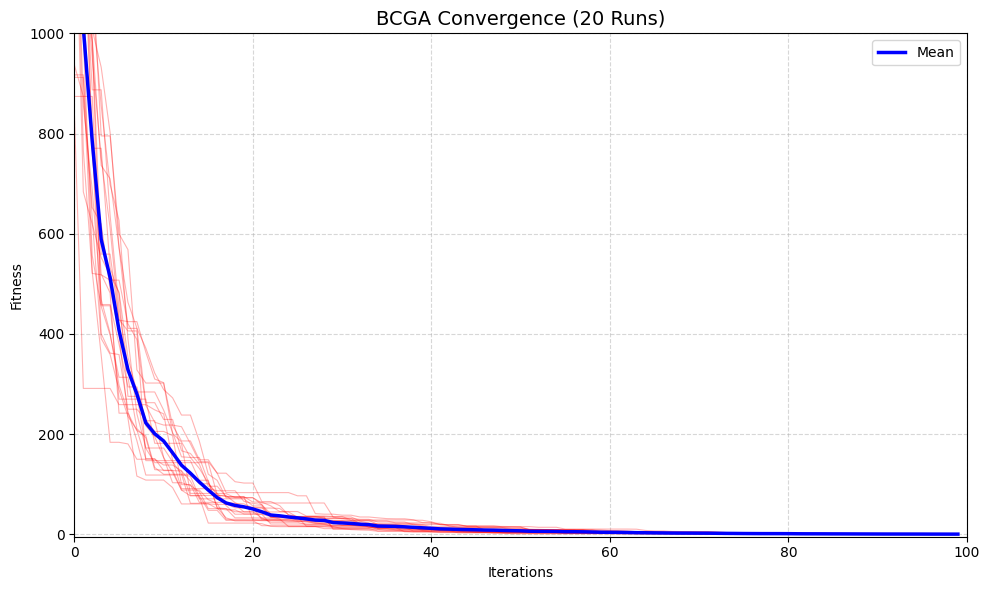

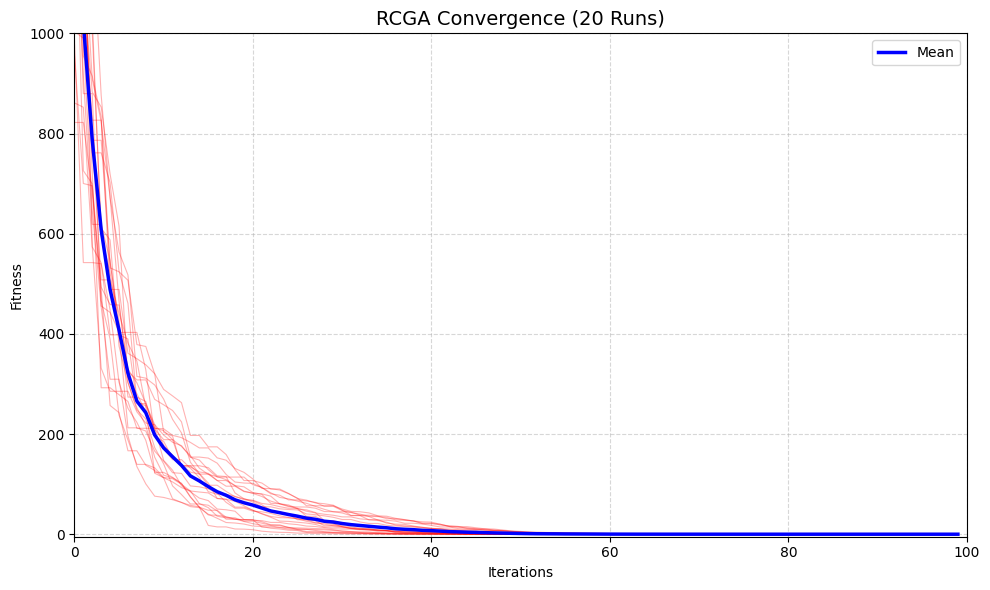

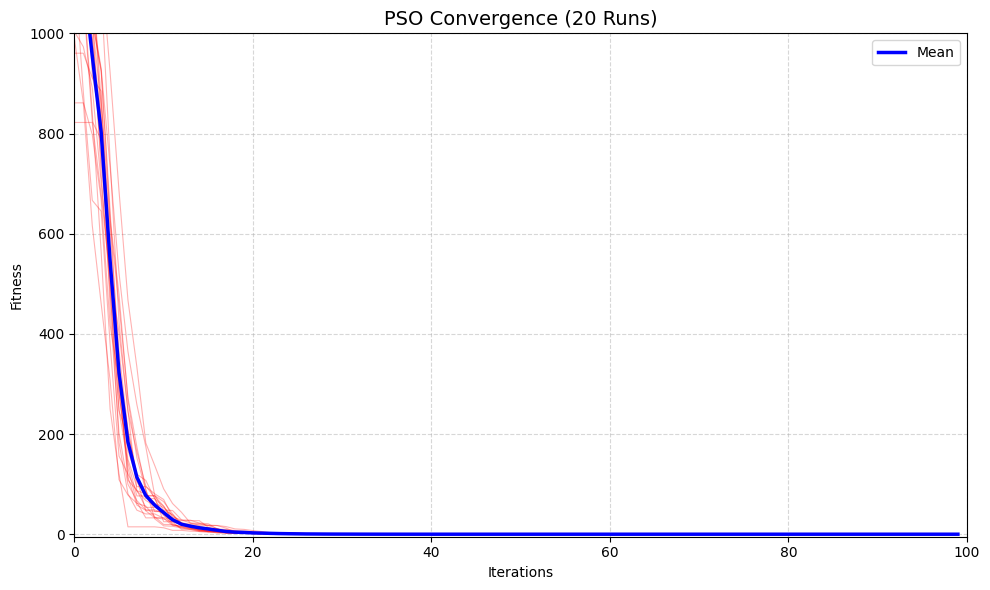

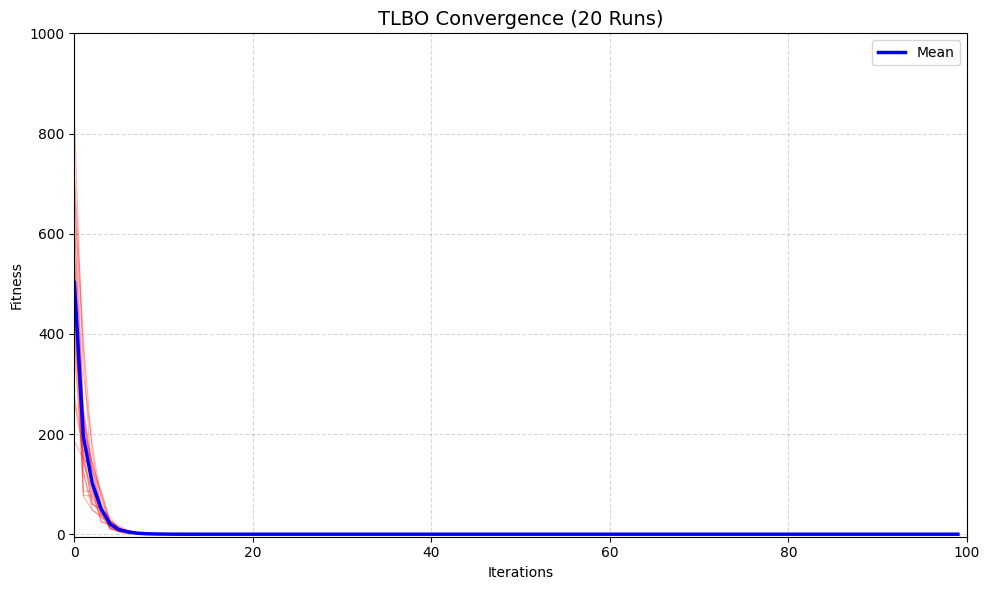

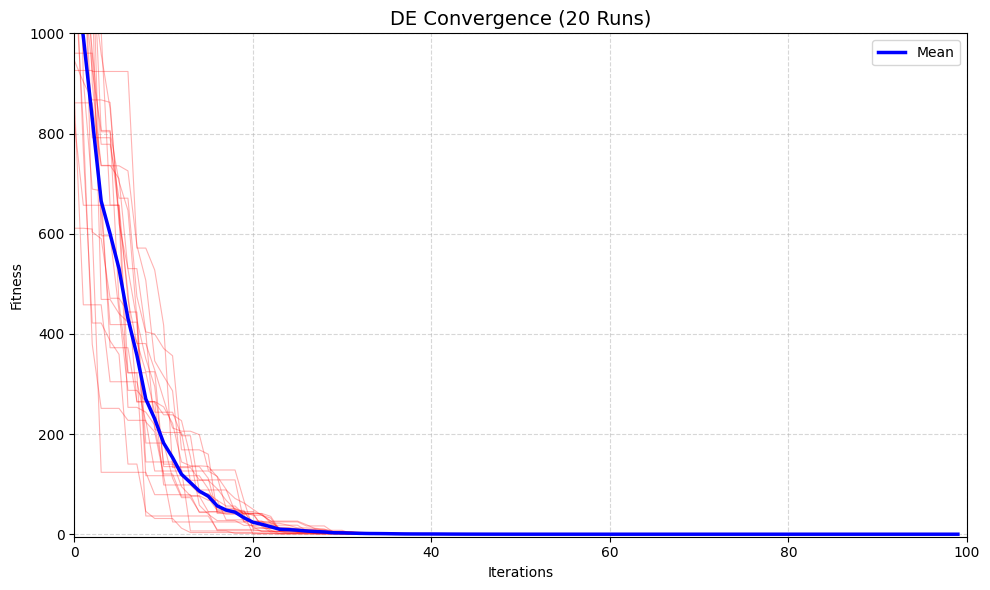

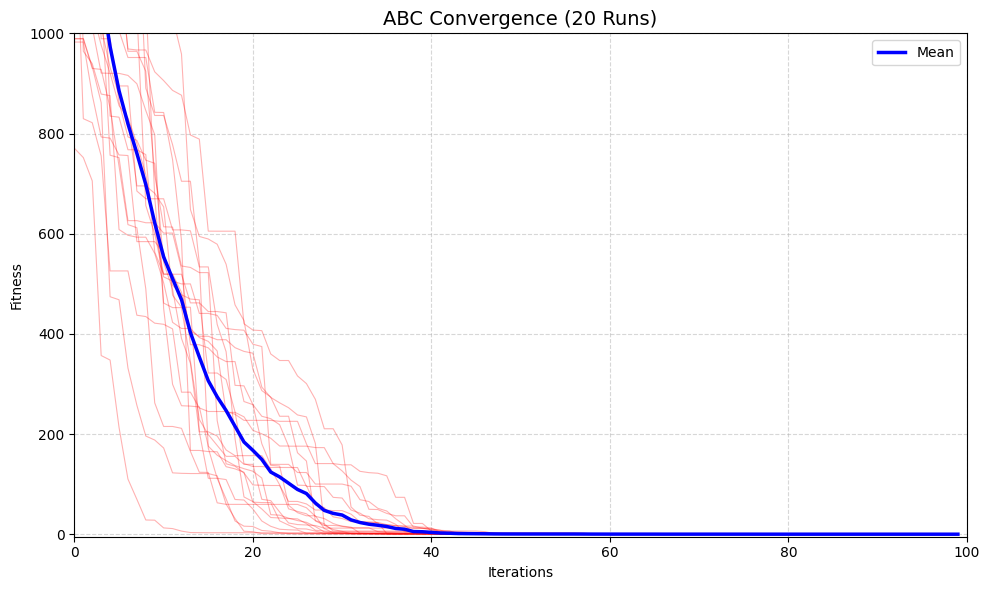

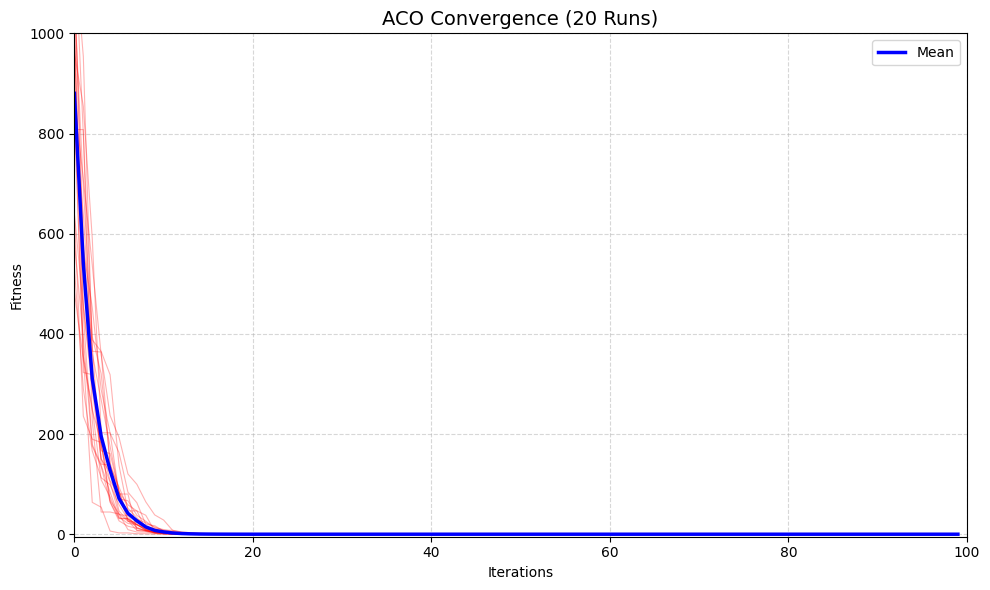

In [ ]:
# Plotting Convergence Curves
for name, histories in all_histories.items():
    plt.figure(figsize=(10, 6))

    # Individual runs (thin lines)
    for run in histories:
        plt.plot(run, color='red', alpha=0.3, linewidth=0.8)

    # Mean curve (bold)
    mean_curve = np.mean(histories, axis=0)
    plt.ylim(-5, 1000)
    plt.xlim(0, MAX_ITERATIONS)
    plt.plot(mean_curve, color='blue', linewidth=2.5, label='Mean')

    plt.title(f'{name} Convergence ({NUM_TRIALS} Runs)', fontsize=14)
    plt.xlabel('Iterations')
    plt.ylabel('Fitness')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

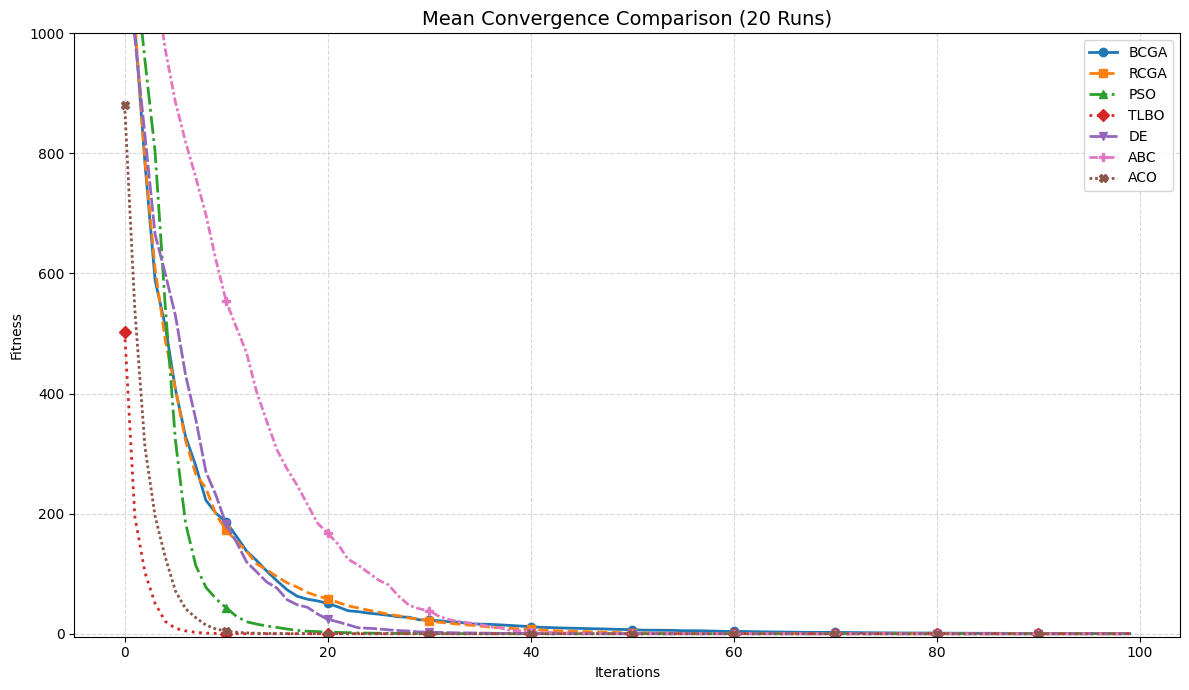

In [18]:
plt.figure(figsize=(12, 7))

colors = {
    'BCGA': '#1f77b4',
    'RCGA': '#ff7f0e',
    'PSO': '#2ca02c',
    'TLBO': '#d62728',
    'DE': '#9467bd',
    'ABC': '#e377c2',
    'ACO': '#8c564b'
}

linestyles = {
    'BCGA': '-',
    'RCGA': '--',
    'PSO': '-.',
    'TLBO': ':',
    'DE': (0, (5, 1)),        # long dash
    'ABC': (0, (3, 1, 1, 1)), # dash-dot-dot
    'ACO': (0, (1, 1))        # dotted
}

markers = {
    'BCGA': 'o',
    'RCGA': 's',
    'PSO': '^',
    'TLBO': 'D',
    'DE': 'v',
    'ABC': 'P',
    'ACO': 'X'
}

for name, histories in all_histories.items():
    mean_curve = np.mean(histories, axis=0)
    plt.plot(mean_curve, label=name, color=colors[name], linewidth=2, linestyle=linestyles[name], marker=markers[name], markevery=10)
plt.ylim(-5, 1000)
plt.title('Mean Convergence Comparison (20 Runs)', fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Fitness')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

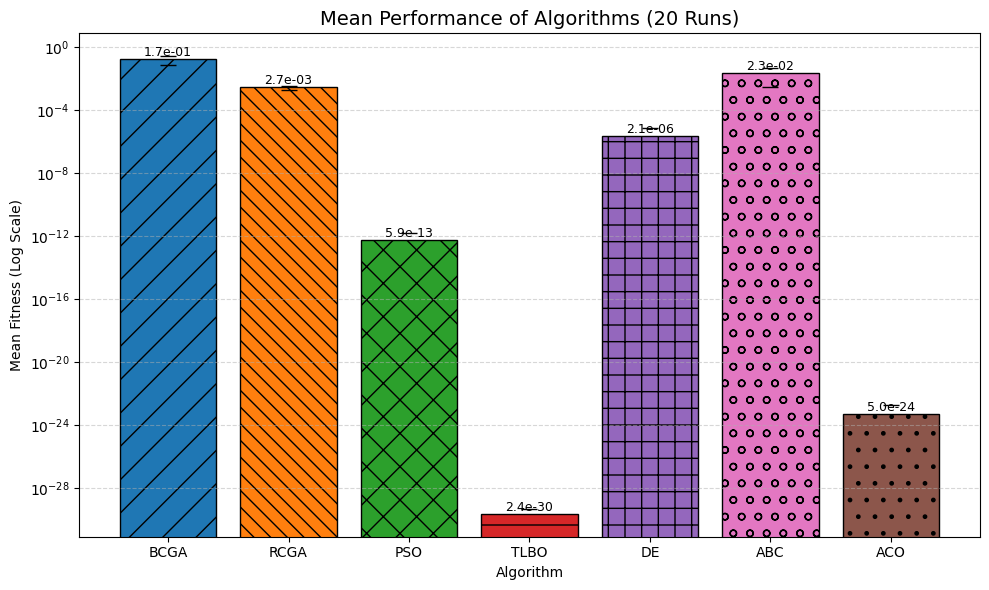

In [ ]:
# Bar Plot: Mean Performance
labels = list(mean_results.keys())
means = np.array(list(mean_results.values()))
stds = np.array(list(std_results.values()))

# Avoid log(0)
safe_means = np.maximum(means, 1e-30)

plt.figure(figsize=(10, 6))

# Hatch patterns
hatches = ['/', '\\\\', 'x', '-', '+', 'o', '.']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#e377c2', '#8c564b']

bars = plt.bar(
    labels,
    safe_means,
    yerr=stds,
    capsize=6,
    color=colors,          
    edgecolor='black',
    error_kw={'elinewidth': 0}
)

# Apply hatches
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.title('Mean Performance of Algorithms (20 Runs)', fontsize=14)
plt.xlabel('Algorithm')
plt.ylabel('Mean Fitness (Log Scale)')
plt.yscale('log')

# Add value labels
for bar, val in zip(bars, means):
    yval = max(val, 1e-30)
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{val:.1e}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

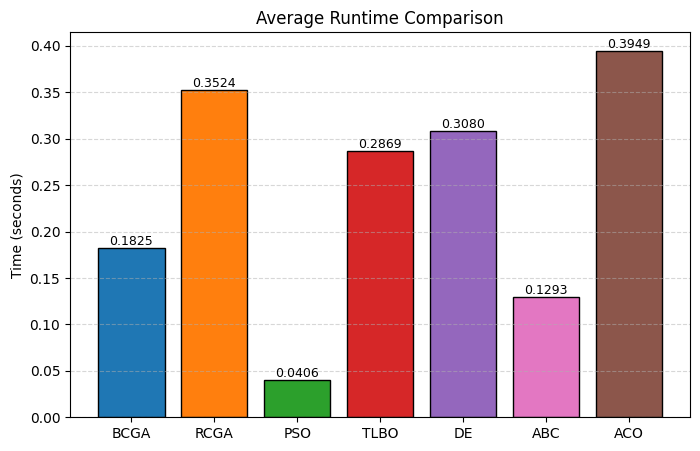

In [22]:
plt.figure(figsize=(8,5))
plt.bar(time_results.keys(), time_results.values(), color=colors, edgecolor='black')
plt.title("Average Runtime Comparison")
plt.ylabel("Time (seconds)")

# Add value labels
for bar, val in zip(bars, time_results.values()):
    yval = max(val, 1e-30)
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )
    
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()